# Лабораторная работа №5
# "Аналитика сотрудников в индустрии гостеприимства штата Калифорния"

ЦЕЛЬ:
- Спрогнозировать  число сотрудников в индустрии гостеприимства штата Калифорния по месяцам 

ЗАДАЧА:
- Построить модель для такого предсказания

ХОД РАБОТЫ:

1) Подготовка
- Загрузить данные
- Проверить монотонность
- Проверить соответствие типов признаков

2) Анализ
- Построить графики временных рядов занятости
- Определить признаки сезонности, тренда и возможные аномалии
- Выполнить тесты  для проверки стационарности ряда
- При необходимости выполнить преобразования 

3) Обучение
- Построить и обучить модель прогнозирования временных рядов
- Сделать прогноз на несколько периодов  
- Оценить точность прогноза с помощью метрик MAE, RMSE.

4) Анализ и интерпретация результатов
- Визуализировать полученный прогноз вместе с исходным рядом
- Интерпретировать выявленные сезонные и трендовые компоненты
- Обсудить влияние сезонности на прогноз

5) Общий вывод

ОПИСАНИЕ ДАННЫХ

Данные лежат в файле lab_5.csv. Набор представляет собой сезонные временные ряды с месячными данными по числу сотрудников в индустрии гостеприимства штата Калифорния. Данные отражают количество работников (в тысячах человек) по месяцам.

In [1]:
import time
import lightgbm as lgb

from phik import phik_matrix
from phik.report import plot_correlation_matrix
from statsmodels.tsa.seasonal import seasonal_decompose

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import kpss

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.model_selection import TimeSeriesSplit

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

## Предварительный анализ и визуализация данных

In [2]:
data = pd.read_csv('lab5.csv', sep=',')

In [3]:
def check_data(name):
    print('общая информация ***************************************************************************************************')
    name.info()
    print('первые 5 строк *****************************************************************************************************')
    display(name.head())
    print('название столбцов **************************************************************************************************')
    display(name.columns)
    print('количество пропусков ***********************************************************************************************')
    print(name.isnull().sum())
    print('количество явных дубликатов ********************************************************************************************')
    print(name.duplicated().sum())
    display(name.describe().T)

In [4]:
check_data(data)

общая информация ***************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       348 non-null    object 
 1   Employees  348 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.6+ KB
первые 5 строк *****************************************************************************************************


,Date,Employees
0,1/1/1990,1064.5
1,2/1/1990,1074.5
2,3/1/1990,1090.0
3,4/1/1990,1097.4
4,5/1/1990,1108.7


название столбцов **************************************************************************************************


Index(['Date', 'Employees'], dtype='object')

количество пропусков ***********************************************************************************************
Date         0
Employees    0
dtype: int64
количество явных дубликатов ********************************************************************************************
0


,count,mean,std,min,25%,50%,75%,max
Employees,348.0,1452.506897,256.604914,1064.5,1238.05,1436.2,1586.3,2022.1


Изменим тип данных Datetime с object на datetime64

In [5]:
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       348 non-null    datetime64[ns]
 1   Employees  348 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.6 KB
None


Чтобы работать с временными рядами, необходимо проверить, в хронологическом ли порядке расположены даты и время. Для этого нужно посмотреть атрибут индекса таблицы is_monotonic. Если порядок соблюдён, атрибут вернёт True, если нет — False:

Установим индекс таблицы равным столбцу Datetime.

In [7]:
data.set_index(data.columns[0], inplace=True) 

In [8]:
check_data(data)

общая информация ***************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 348 entries, 1990-01-01 to 2018-12-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Employees  348 non-null    float64
dtypes: float64(1)
memory usage: 5.4 KB
первые 5 строк *****************************************************************************************************


,Employees
Date,
1990-01-01,1064.5
1990-02-01,1074.5
1990-03-01,1090.0
1990-04-01,1097.4
1990-05-01,1108.7


название столбцов **************************************************************************************************


Index(['Employees'], dtype='object')

количество пропусков ***********************************************************************************************
Employees    0
dtype: int64
количество явных дубликатов ********************************************************************************************
10


,count,mean,std,min,25%,50%,75%,max
Employees,348.0,1452.506897,256.604914,1064.5,1238.05,1436.2,1586.3,2022.1


In [9]:
if data.index.is_monotonic_increasing:
    print("Индекс монотонно возрастающий.")
else:
    print("Индекс не монотонно возрастающий.")

Индекс монотонно возрастающий.


Вывод 1:
- Пропусков в датасете нет, дубликатов тоже, значения признаков соответствуют заданным типам => данные в норме, можно приступать к анализу данных)

ВАЖНО отметить что данные расположены в хронологическом порядке.

- datetime (англ. «дата-время») — значение даты и времени на временной оси. Переменная называется так же, как и тип данных datetime.

-  Количество заказов сотрудников в столбце `Employees`.

Преобразован столбец Date в тип datatime64, изменена инденксация)

## Анализ

Построим график временного ряда за все время которое есть в таблице

In [10]:
def time_series_graph(DATA, TITLE):
    plt.figure(figsize=(15, 7))
    plt.plot(DATA)
    plt.title(TITLE)
    plt.grid(True)
    plt.show();

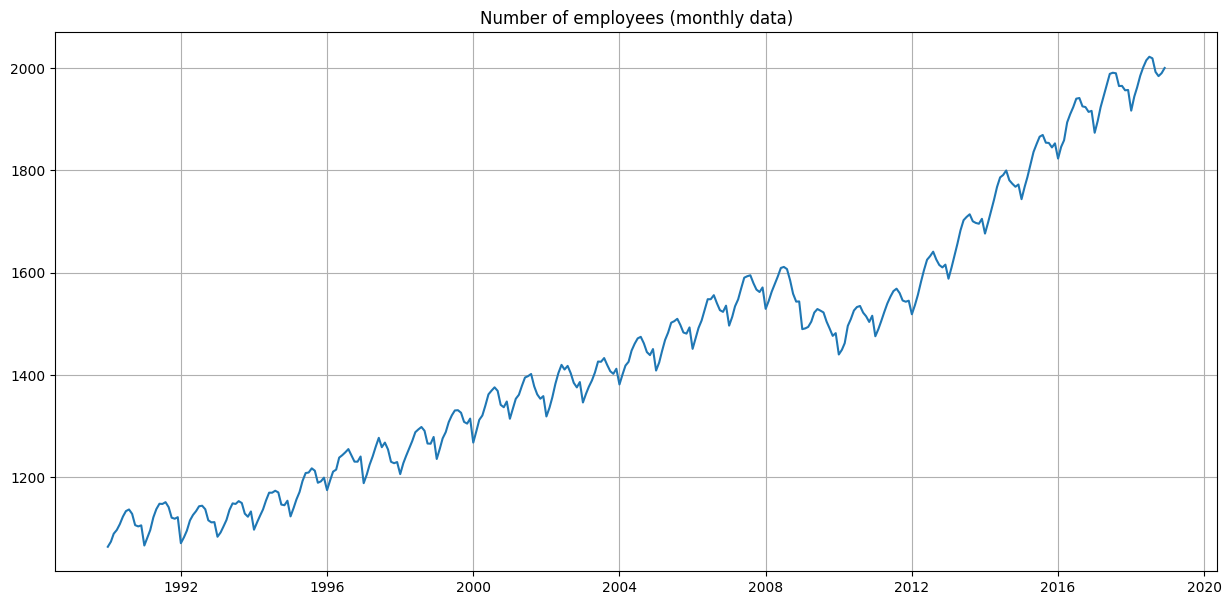

In [11]:
time_series_graph(data, 'Number of employees (monthly data)')

- Стационарные временные ряды (англ. stationary time series) — это ряды, у которых среднее и стандартное отклонение не меняются. Когда среднее и стандартное отклонение первого ряда меняется медленнее второго, то первый ряд «более стационарный», чем второй.

Очевидно, что наш график нестационарный, так как меняется среднее значение, а именно увеличивается. То есть за прошедшие года количество сотрудников в индустрии гостеприимства штата Калифорния увеличилось, конечно с 2008 по 2012 видим небольшое спад, но потом снова начинается рост) Данные мы видим за 29 лет

- Нестационарные ряды (англ. nonstationary time series) прогнозировать сложнее: их свойства меняются слишком быстро.

Построим график временного ряда за первый и последний года 

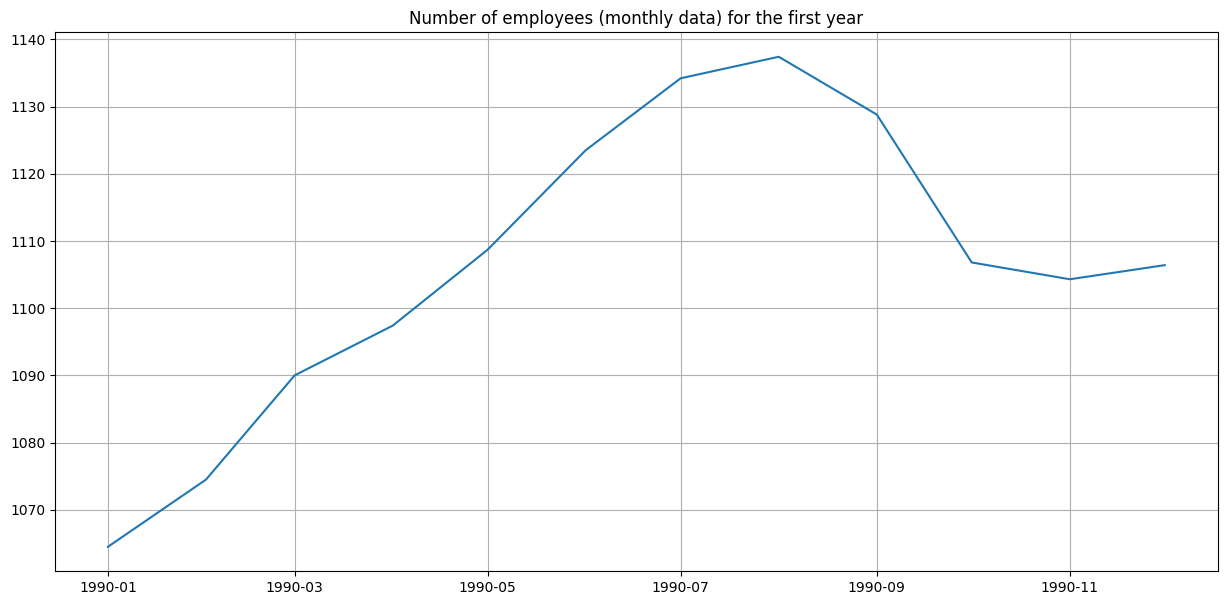

In [12]:
time_series_graph(data['1990-01-01':'1990-12-01'], 'Number of employees (monthly data) for the first year')

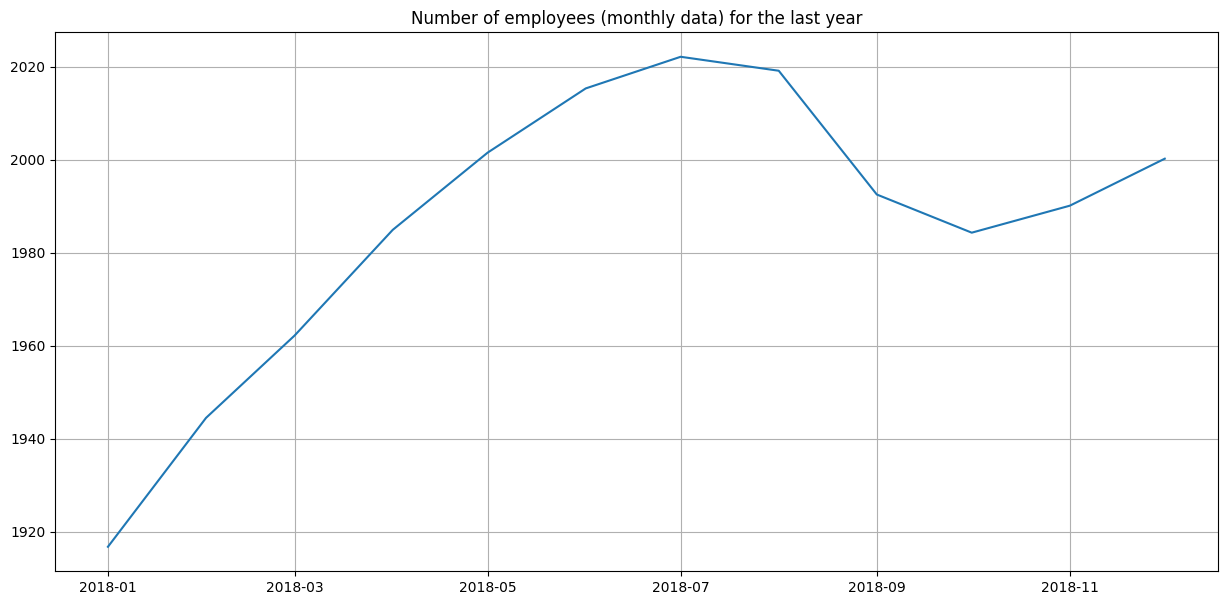

In [13]:
time_series_graph(data['2018-01-01':'2018-12-01'], 'Number of employees (monthly data) for the last year')

Проанализируем рандомные два месяца за первый и последний года

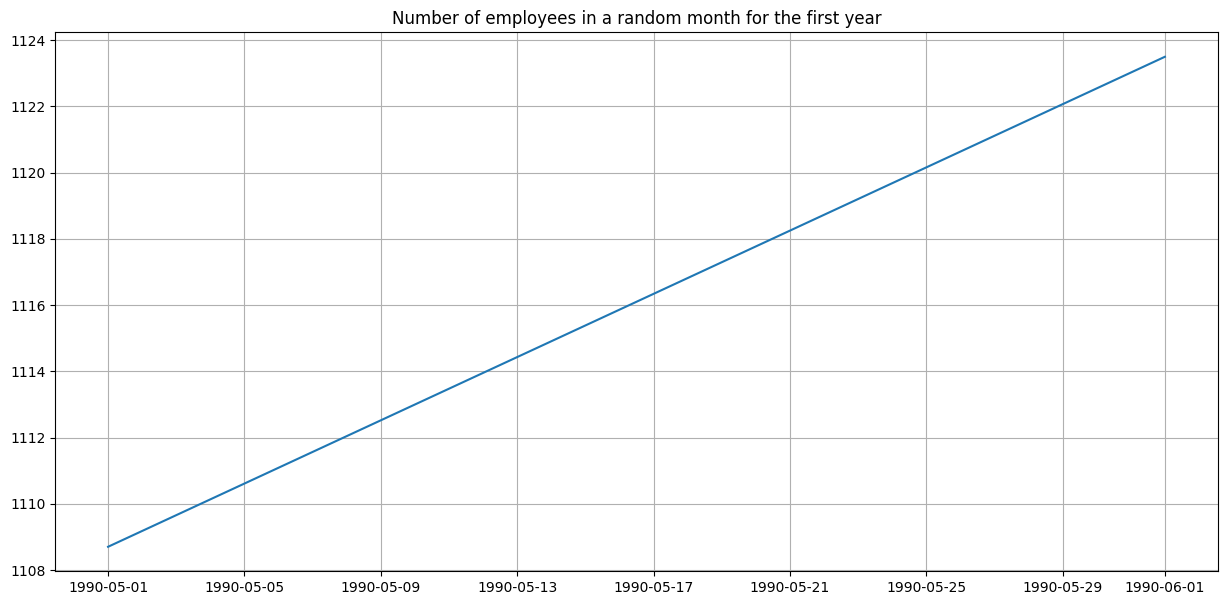

In [14]:
time_series_graph(data['1990-05-01':'1990-06-01'], 'Number of employees in a random month for the first year')

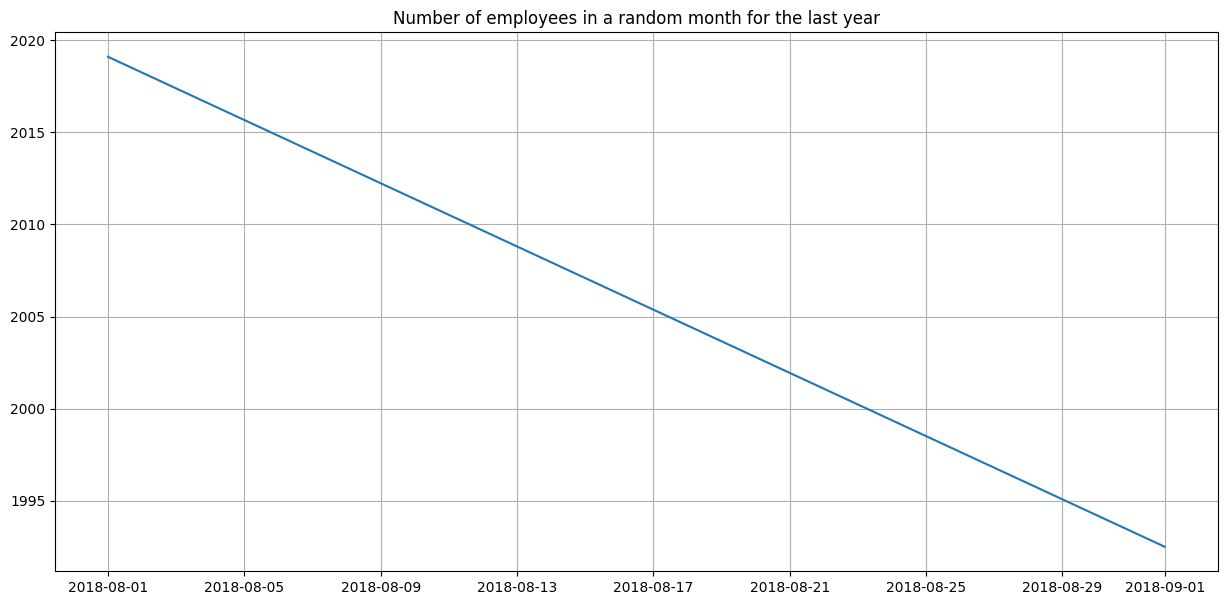

In [15]:
time_series_graph(data['2018-08-01':'2018-09-01'], 'Number of employees in a random month for the last year')

Невооруженным глазом видно, что общее количество сотрудников с 1990 года по 2019 увеличилось почти вдвое, также у обоих графиков наблюдается рост количества сотрудников индустрии с января по июль, а наибольшее количество сотрудников наблюдается в июне, далее наблюдается спад с июля по октябрь, в октябре наблюдается минимальное количество сотрудников. То есть максимальное количество сотрудников достигается в определенные летние месяцы, а минимальное количество сотрулников наблюдается осенью.

Изучим трендовую, сезонную и шумовую состовляющие данных и построим соответствующие графики

- Тренд (англ. trend) — плавное изменение среднего значения ряда без повторяющихся закономерностей. Например, ежегодное увеличение объёма продаж авиабилетов. А в нашем случае увеличение числа сотрудников.

- Сезонность (англ. seasonality) — циклично повторяющиеся закономерности во временном ряду. Допустим, рост продаж авиабилетов летом. В нашем случае рост количества сотрудников с январь по июль и спад с июля по ноябрь(декабрь).
- Остаток (англ. residuals). Это компонента, которая не объясняется трендом и сезонностью, это шум.

В модуле tsa.seasonal (от англ. time series analysis, «анализ временных рядов») библиотеки statsmodels (англ. «статистические модели») есть функция seasonal_decompose() (англ. «разбить на части»). Она раскладывает временной ряд на три составляющие: тренд, сезонность и остаток (англ. residuals). Это компонента, которая не объясняется трендом и сезонностью, это шум.

Функция seasonal_decompose() принимает временной ряд, а возвращает объект структуры DecomposeResult (англ. «результат разделения»). В нём есть нужные атрибуты:

- decomposed.trend — тренд;
- decomposed.seasonal — сезонная составляющая;
- decomposed.resid — остаток декомпозиции.

In [16]:
decomposed = seasonal_decompose(data) 

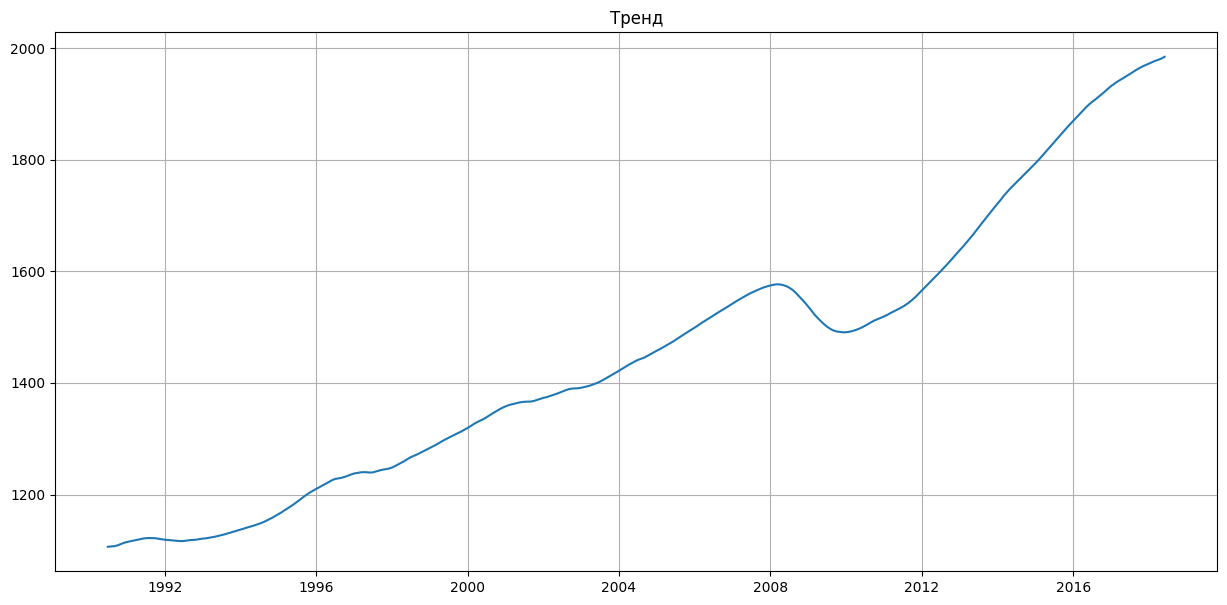

In [17]:
time_series_graph(decomposed.trend, 'Тренд')

Построим график со скользящим средним, такой параметр, как размер окна, воьзмем 6)

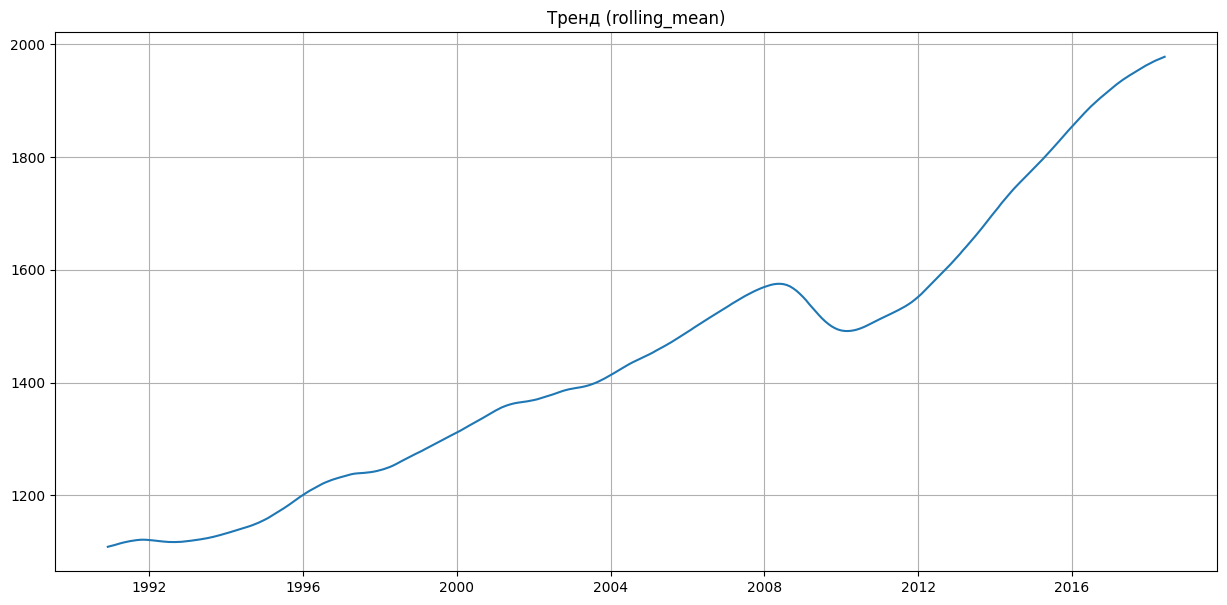

In [18]:
time_series_graph(decomposed.trend.rolling(6).mean(), 'Тренд (rolling_mean)')

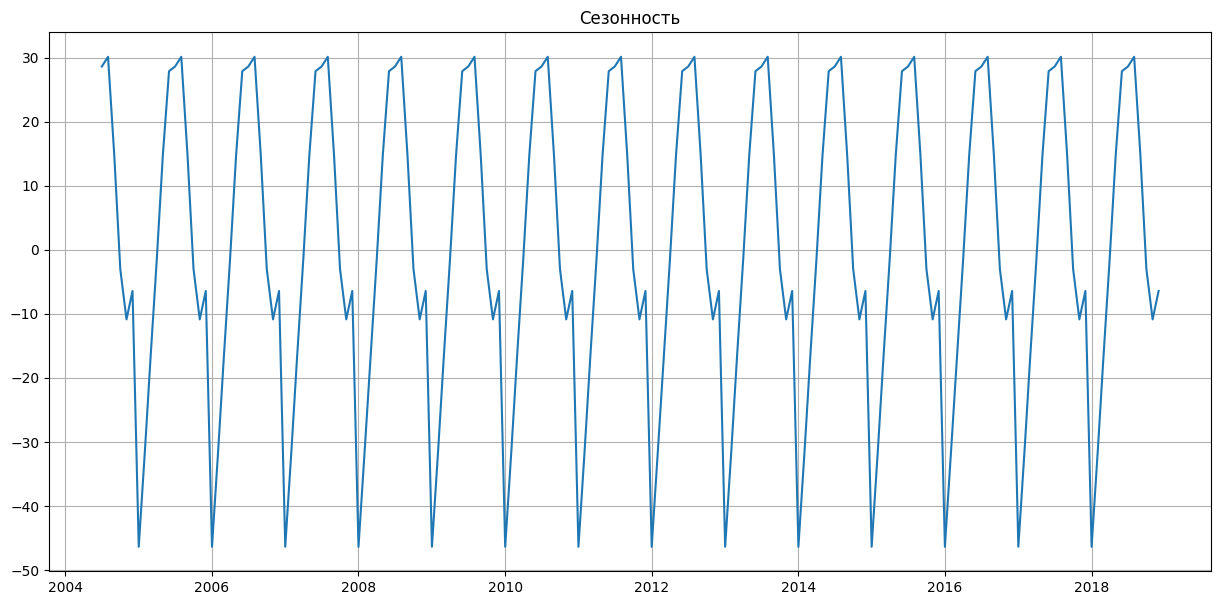

In [19]:
time_series_graph(decomposed.seasonal.tail(174), 'Сезонность' )

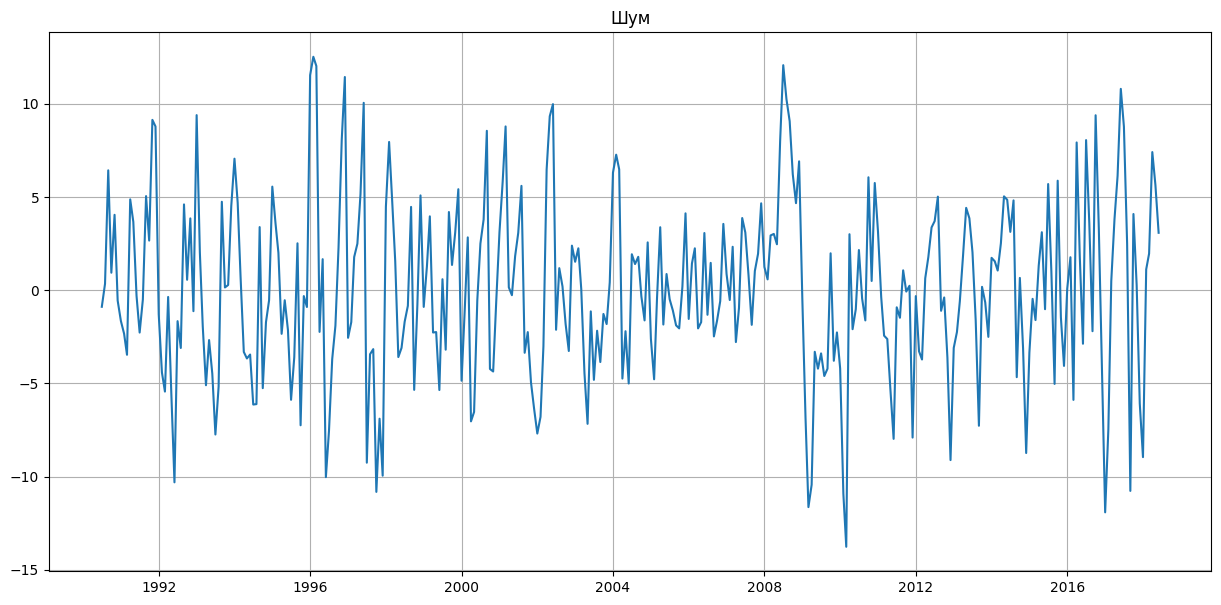

In [20]:
time_series_graph(decomposed.resid, 'Шум')

Для проверки стационарности давайте проведем обобщенный тест Дикки-Фуллера на наличие единичных корней. Для этого в модуле statsmodels есть функция adfuller():

In [21]:
test = sm.tsa.adfuller(data)
print('adf: ', test[0])
print('p-value: ', test[1])
print('Critical values: ', test[4])
if test[0] > test[4]['5%']: 
    print('есть единичные корни, ряд не стационарен')
else:
    print('единичных корней нет, ряд стационарен')

adf:  0.9012844235569718
p-value:  0.9931070655289933
Critical values:  {'1%': -3.4503224123605194, '5%': -2.870338478726661, '10%': -2.571457612488522}
есть единичные корни, ряд не стационарен


In [22]:
stat, p, lags, crit_values = kpss(data, regression='c')
print('KPSS Statistic:', stat)
print('p-value:', p)
print('Critical Values:', crit_values)
if p < 0.05:
    print("Ряд не стационарен")
else:
    print("Ряд стационарен")

KPSS Statistic: 2.811347117430525
p-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Ряд не стационарен


Вывод 2:
- Итак, начнем с тренда, на протяжении 29 лет наблюдается явный рост количества сотрудников, тренд есть.
- Конечно же есть сезонные колебания, к лету сотрудников становиться больше, а к концу года меньше.
- Также присутствуют некоторые отклонения от общего тренда, в 2010-2011 годах общее количество сотрудников "просело", а с 2012 года начался более быстрый рост
- По результатам двух тестов ряд оказался не стационарным, впрочем неудивительно, чтд)

## Обучение

In [23]:
features = data.copy()

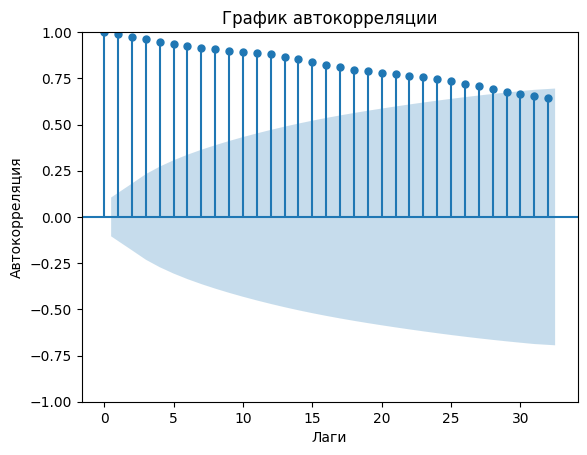

In [24]:
sm.graphics.tsa.plot_acf(features, lags=32)
plt.title('График автокорреляции')
plt.xlabel('Лаги')
plt.ylabel('Автокорреляция')
plt.show()

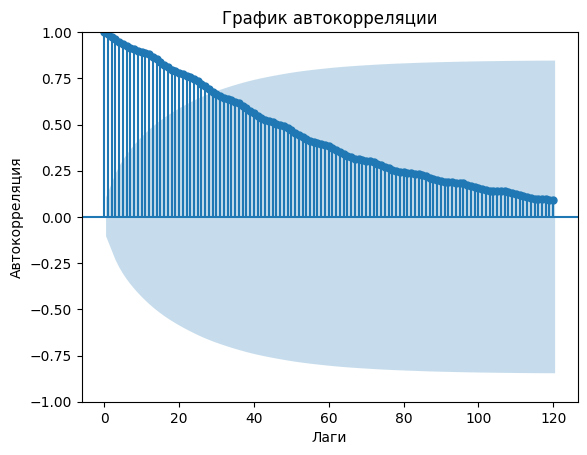

In [25]:
sm.graphics.tsa.plot_acf(features, lags=120)
plt.title('График автокорреляции')
plt.xlabel('Лаги')
plt.ylabel('Автокорреляция')
plt.show()

- Сильный спад автокорреляции с лагами → ряд стационарный (значения «забывают» предыдущие). НЕ НАШ СЛУЧАЙ

- Медленный спад или сохраняющаяся корреляция → ряд нестационарный (есть тренд или сезонность). НАШЕ

- Пиковые значения на регулярных интервалах → указывает на сезонность. НАШЕ

Учтем, что данные по месяцам, а колонка day не несёт никакой полезной информации — она всегда будет равна 1.

In [26]:
def make_features(DATA, max_lag, rolling_mean_size):
    for lag in range(1, max_lag + 1):
        DATA[f'lag_{lag}'] = DATA['Employees'].shift(lag)
    
    DATA['rolling_mean'] = DATA['Employees'].shift().rolling(6).mean()
    DATA.dropna(inplace=True)
    
    return DATA

In [27]:
features = make_features(features, 24, 12)
features

,Employees,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
Date,,,,,,,,,,,,,,,,,,,,,
1992-01-01,1071.5,1122.3,1119.3,1121.4,1141.9,1151.7,1148.2,1148.6,1138.1,1121.9,...,1128.8,1137.4,1134.2,1123.5,1108.7,1097.4,1090.0,1074.5,1064.5,1134.133333
1992-02-01,1083.0,1071.5,1122.3,1119.3,1121.4,1141.9,1151.7,1148.2,1148.6,1138.1,...,1106.8,1128.8,1137.4,1134.2,1123.5,1108.7,1097.4,1090.0,1074.5,1121.350000
1992-03-01,1096.0,1083.0,1071.5,1122.3,1119.3,1121.4,1141.9,1151.7,1148.2,1148.6,...,1104.3,1106.8,1128.8,1137.4,1134.2,1123.5,1108.7,1097.4,1090.0,1109.900000
1992-04-01,1116.0,1096.0,1083.0,1071.5,1122.3,1119.3,1121.4,1141.9,1151.7,1148.2,...,1106.4,1104.3,1106.8,1128.8,1137.4,1134.2,1123.5,1108.7,1097.4,1102.250000
1992-05-01,1126.6,1116.0,1096.0,1083.0,1071.5,1122.3,1119.3,1121.4,1141.9,1151.7,...,1067.0,1106.4,1104.3,1106.8,1128.8,1137.4,1134.2,1123.5,1108.7,1101.350000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-01,2019.1,2022.1,2015.3,2001.5,1984.9,1962.2,1944.5,1916.8,1957.2,1956.6,...,1945.4,1923.4,1897.3,1873.6,1916.4,1914.4,1923.8,1925.2,1941.5,1988.416667
2018-09-01,1992.5,2019.1,2022.1,2015.3,2001.5,1984.9,1962.2,1944.5,1916.8,1957.2,...,1967.4,1945.4,1923.4,1897.3,1873.6,1916.4,1914.4,1923.8,1925.2,2000.850000
2018-10-01,1984.3,1992.5,2019.1,2022.1,2015.3,2001.5,1984.9,1962.2,1944.5,1916.8,...,1988.7,1967.4,1945.4,1923.4,1897.3,1873.6,1916.4,1914.4,1923.8,2005.900000


In [28]:
X = features.drop(['Employees'], axis=1)
y = features['Employees']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.1)

### Линейная регрессия

In [29]:
train_models=[]

In [30]:
model_lr = LinearRegression()
param_grid = {'fit_intercept': [True, False], 'copy_X': [True, False], 'n_jobs': [1, -1]}

In [31]:
tscv = TimeSeriesSplit(n_splits=5)
gs= GridSearchCV(estimator=model_lr, param_grid=param_grid, cv=tscv, scoring='neg_mean_squared_error')
gs.fit(X_train, y_train)

best_params_lr = gs.best_params_
best_model_lr = LinearRegression(**best_params_lr)

start_fit_time = time.time()

best_model_lr.fit(X_train, y_train)

fit_time_lr = time.time() - start_fit_time

In [32]:
start_predict_time = time.time()
predictions_lr = best_model_lr.predict(X_train)
predict_time_lr = time.time() - start_predict_time

In [33]:
cv_rmse_lr = cross_val_score(best_model_lr, X_train, y_train, scoring='neg_mean_squared_error', cv=tscv)
rmse_lr = np.sqrt(-cv_rmse_lr)

In [34]:
cv_mae_lr = cross_val_score(best_model_lr, X_train, y_train, scoring='neg_mean_absolute_error', cv=tscv)
mae_lr = -cv_mae_lr

In [35]:
print("Лучшие гиперпараметры модели LinearRegression: ", best_params_lr)
print("RMSE LinearRegression (кросс-валидация): %.2f" % rmse_lr.mean())
print("MAE LinearRegression (кросс-валидация): %.2f" % mae_lr.mean())

Лучшие гиперпараметры модели LinearRegression:  {'copy_X': True, 'fit_intercept': False, 'n_jobs': 1}
RMSE LinearRegression (кросс-валидация): 7.80
MAE LinearRegression (кросс-валидация): 6.04


In [36]:
train_models.append([best_model_lr, rmse_lr, mae_lr])

### LightGBM

In [37]:
param_grid = {'n_estimators': [n for n in range(10, 200, 10)], 'num_leaves': [n for n in range(1, 20, 1)]}

model = lgb.LGBMRegressor(random_state=12345, verbose=-1)

gs = GridSearchCV(estimator=model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=tscv,
                          verbose=0)

gs.fit(X_train, y_train)

best_params_lg = gs.best_params_
best_model_lg = LGBMRegressor(**best_params_lg)

start_fit_time = time.time()

best_model_lg.fit(X_train, y_train)

fit_time_lg = time.time() - start_fit_time

In [38]:
start_predict_time = time.time()
predictions_lg = best_model_lg.predict(X_train)
predict_time_lg = time.time() - start_predict_time

In [39]:
cv_rmse_lg = cross_val_score(best_model_lg, X_train, y_train, scoring='neg_mean_squared_error', cv=tscv)
rmse_lg = np.sqrt(-cv_rmse_lg)

In [40]:
cv_mae_lg = cross_val_score(best_model_lg, X_train, y_train, scoring='neg_mean_absolute_error', cv=tscv)
mae_lg = -cv_mae_lg

In [41]:
print("Лучшие гиперпараметры модели LGBMRegressor: ", best_params_lg)
print("RMSE LGBMRegressor (кросс-валидация): %.2f" % rmse_lg.mean())
print("MAE LGBMRegressor (кросс-валидация): %.2f" % mae_lg.mean())

Лучшие гиперпараметры модели LGBMRegressor:  {'n_estimators': 190, 'num_leaves': 7}
RMSE LGBMRegressor (кросс-валидация): 93.81
MAE LGBMRegressor (кросс-валидация): 81.91


In [42]:
train_models.append([best_model_lg, rmse_lg, mae_lg])

## Анализ и интерпретация результатов

In [43]:
results = pd.DataFrame({'Model': ['Linear Regression', 'LightGBM'], 'Время обучения(с)': [fit_time_lr, fit_time_lg], 'Время предсказания (с)': [predict_time_lr, predict_time_lg], 'RMSE (кросс-валидация)': [rmse_lr.mean(), rmse_lg.mean()], 'MAE (кросс-валидация)': [mae_lr.mean(), mae_lg.mean()]})
display(results)

,Model,Время обучения(с),Время предсказания (с),RMSE (кросс-валидация),MAE (кросс-валидация)
0,Linear Regression,0.000000,0.005412,7.804923,6.038582
1,LightGBM,0.049447,0.008253,93.808128,81.910829


In [44]:
final = pd.DataFrame(train_models, columns=['model', 'rmse_train', 'mae_train'])

In [45]:
rmse_test = np.sqrt(mean_squared_error(y_test, best_model_lr.predict(X_test)))
print("RMSE Linear Regression на тестовой выборке: %.2f" % rmse_test)

RMSE Linear Regression на тестовой выборке: 7.48


In [46]:
test_models = []

In [47]:
def display_result(target, pred, rmse):
    final = target.to_frame().reset_index()
    final['prediction'] = pd.Series(pred)
    final.set_index('Date', inplace=True)
    
    time_series_graph(final, 'RMSE='+str(rmse))

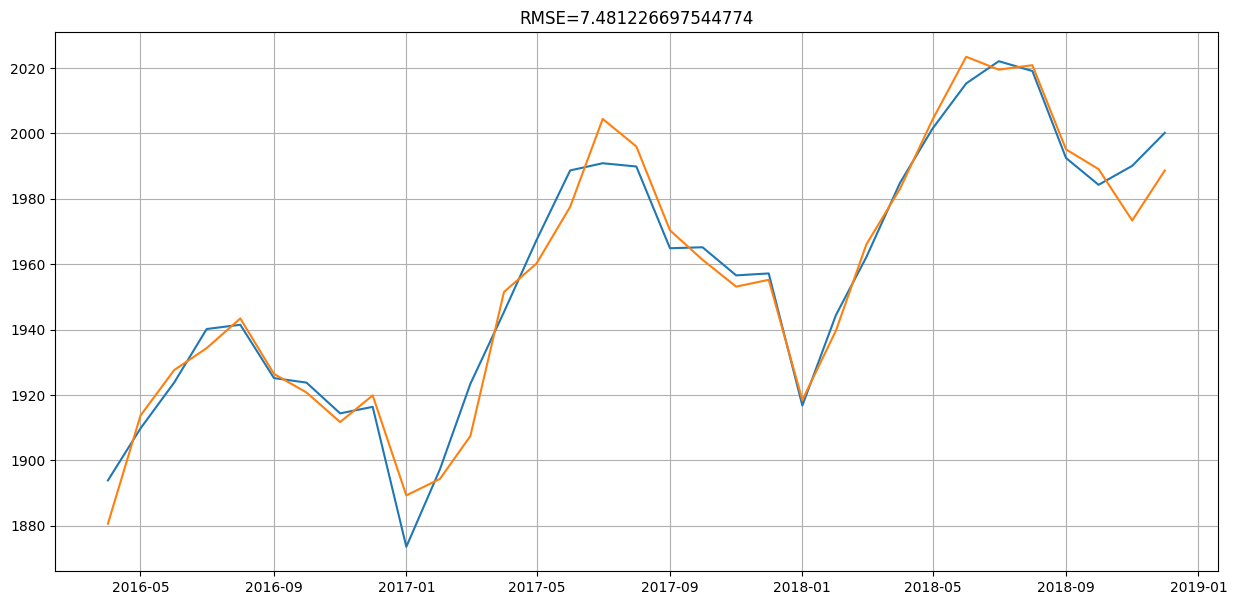

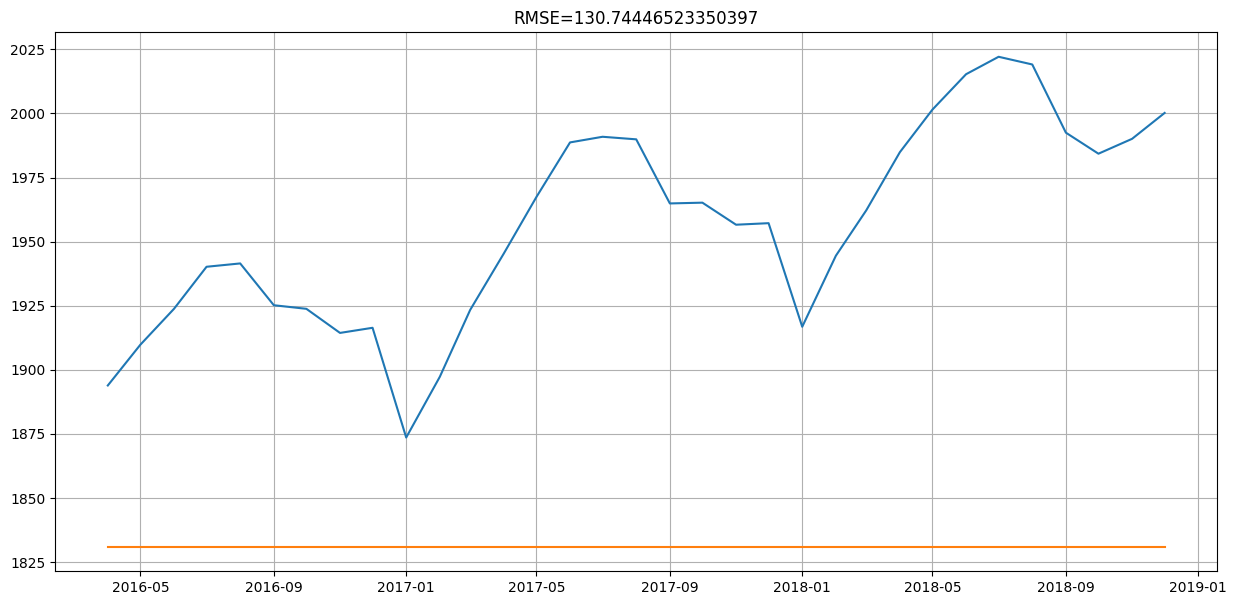

In [48]:
for i in range(len(train_models)):
    predictions = train_models[i][0].predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    display_result(y_test, predictions, rmse)
    test_models.append(rmse)

Теперь просто поменяем период предсказания, сократив его ----> (возьмем годик)

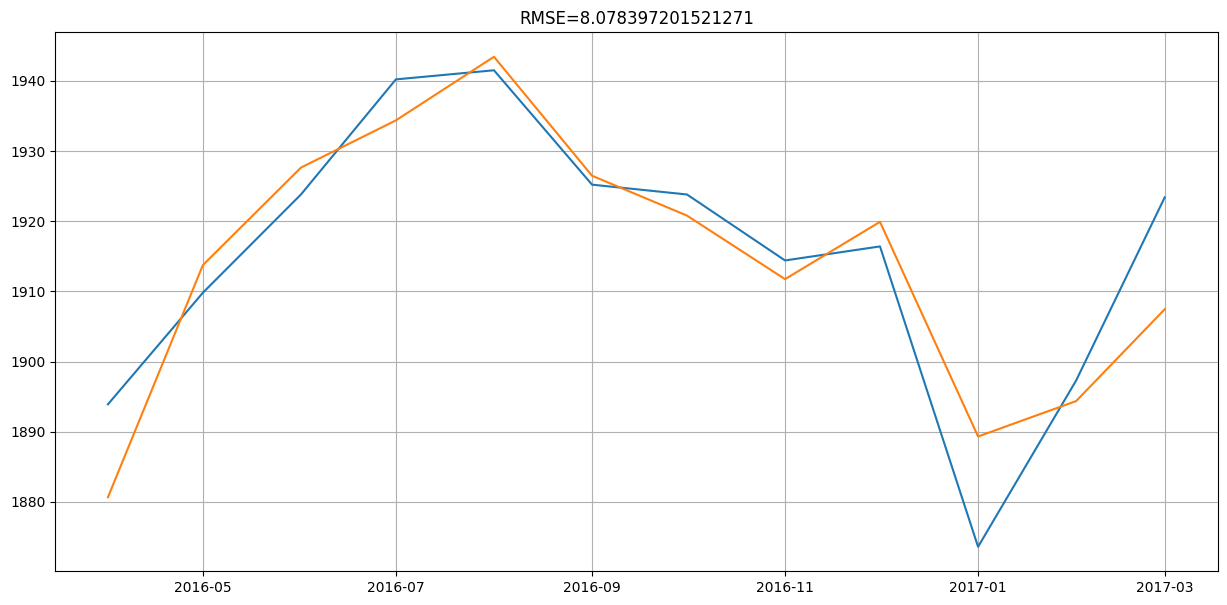

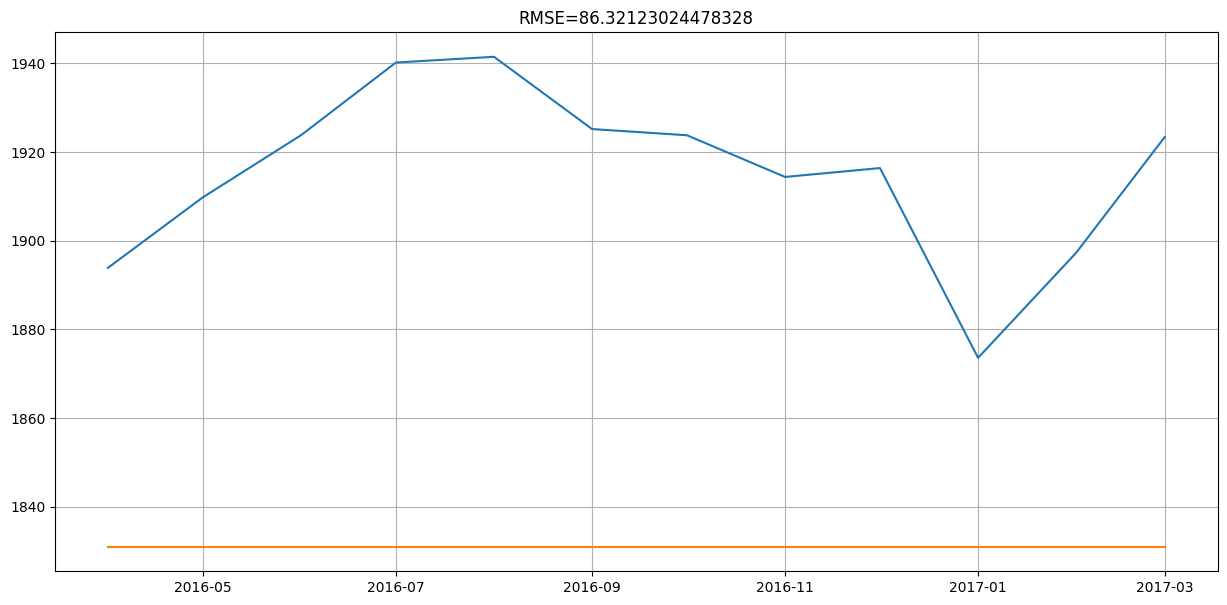

In [49]:
n_steps = 12
test_models = []

for i in range(len(train_models)):
    model = train_models[i][0]
    
    X_test_short = X_test.iloc[:n_steps]
    y_test_short = y_test.iloc[:n_steps]
    
    predictions = model.predict(X_test_short)
    rmse = np.sqrt(mean_squared_error(y_test_short, predictions))
    test_models.append(rmse)
    
    display_result(y_test_short, predictions, rmse)

Ладно, модель LightGBM это реально угар, на нее даже не смотрим)

Видно, что LightGBM суперплохо справляется на тествовой выборке ее даже не рассматриваем ни сейчас, не после. 

Модель линейной регрессии имеет намного меньшее RMSE и отлично ведет себя и на пиковых ситуациях и также отлично улавливает тренд и сезонность), также ее время обучения и предсказания маленькое, что тоже очень хорошо), поэтому модель LinearRegression:  {'copy_X': True, 'fit_intercept': False, 'n_jobs': 1} можно смело рекомендовать заказчику.

## Общий вывод

ВРЕМЕННОЙ РЯД показывает УСТОЙЧИВЫЙ ВОСХОДЯЩИЙ ТРЕНД: занятость в индустрии гостеприимства Калифорнии постепенно растёт, что отражает развитие туризма и экономики штата. На этом фоне видна ярко выраженная сезонность — рост числа работников летом (июнь–август) и спад зимой (декабрь–январь). Это связано с туристическими потоками: в тёплое время года спрос на персонал в отелях и ресторанах значительно выше.

СЕЗОННОСТЬ заметно ВЛИЯЕТ НА ПРОГНОЗ: модель хорошо улавливает повторяющиеся колебания, но немного сглаживает пики и минимумы, то есть не всегда точно воспроизводит экстремальные значения. В целом СЕЗОННОСТЬ ПОМОГАЕТ УЛУЧШИТЬ ТОЧНОСТЬ ПРЕДСКАЗАНИЙ, поскольку поведение ряда стабильно повторяется из года в год.

Данные по числу работников в индустрии гостеприимства Калифорнии имеют выраженную годовую сезонность и восходящий тренд. Сезонность напрямую связана с туристической активностью и оказывает решающее влияние на прогноз. Модель корректно улавливает сезонный ритм, однако имеет тенденцию слегка сглаживать экстремальные колебания, что типично для статистических и машинных методов прогнозирования.

Работа выполнена Гареевой Д.Р (507540), j4150